In [1]:
from scipy.linalg import dft
import numpy as np


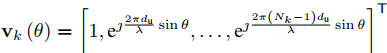

In [2]:
def cal_stering_vec_v(th,Nk,lb,du):
  #Calculates the steering vector for Nk elements (e.g., User ULA).
  k=np.arange(Nk)
  b_p_s=(2*np.pi*du/lb)*np.sin(th)
  v=np.exp(1j*k*b_p_s)
  return v.reshape(-1,1)

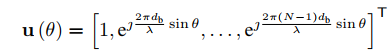

In [3]:
def cal_stering_vec_u(th,N,lb,db):
  k=np.arange(N)
  u=np.exp(1j*k*(2*np.pi*db/lb)*np.sin(th))
  return u.reshape(-1,1)

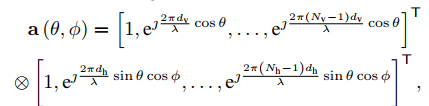

In [4]:
def cal_stering_vec_array_response(th,phi,Nv,Nh,dv,dh,lb):
  k=np.arange(Nv)
  beta_v=(2*np.pi*dv/lb)*np.cos(th)
  a_v=np.exp(1j*k*beta_v).reshape(-1,1)
  l=np.arange(Nh)
  beta_h=(2*np.pi*dh/lb) * np.sin(th) * np.cos(phi)
  a_h=np.exp(1j*l*beta_h).reshape(-1,1)
  a=np.kron(a_v,a_h)
  return a


In [ ]:
def cal_dk(x_user_center,y_user_center,z_user_center,x_ris,y_ris,z_ris):
  # select_x_y = np.random.randint(1, 3)
  # if select_x_y == 1:
  #   x_user=np.random.uniform(-r, r)+x_user_center
  #   y_user_center=(r**2-(x_user-x_user_center)**2)+y_user_center
  #   x_user_center=x_user
  # else:
  #   y_user=np.random.uniform(-r, r)
  #   x_user_center=(r**2-(y_user-y_user_center)**2)+x_user_center
  #   y_user_center=y_user

  radius_k = np.random.uniform(0, r)
  angle_k = np.random.uniform(0, 2 * np.pi)
  x_user = x_user_center + radius_k * np.cos(angle_k)
  y_user = y_user_center + radius_k * np.sin(angle_k)
  z_user = z_user_center

  dk = ((x_user - x_ris)**2 + (y_user - y_ris)**2 + (z_user - z_ris)**2)**0.5
  #dk=((x_user_center-x_ris)**2+(y_user_center-y_ris)**2+(z_user_center-z_ris)**2)**0.5
  dk=dk/1000
  return dk

In [ ]:
def cal_mu_k(fo, x_user_center, y_user_center, z_user_center, x_ris, y_ris, z_ris):
    """
    Calculate path loss coefficient using paper's free-space path loss model:
    -10log10(μk) = 92.5 + 20log10[f0(GHz)] + 20log10[dk(km)]
    Therefore: μk = 10^(-9.25) * (f0 * dk)^(-2)
    """
    dk = cal_dk(x_user_center, y_user_center, z_user_center, x_ris, y_ris, z_ris)
    f0_ghz = fo / 1e9
    mu_k = (10**(-9.25) * (f0_ghz * dk)**(-2))
    return mu_k

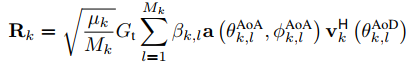

In [ ]:
def cal_Rk_matrix(Gt, Nv, Nh, Nk, dv, du, dh, lambda_val, Mk,
                  fo_hz, xuc, yuc, zuc, xris, yris, zris):
    """
    Paper Eq.(4): Rk = sqrt(μk/Mk)*Gt * sum_l beta_kl * a(AoA)*vk^H(AoD)
    Original implementation with proper scaling for non-zero results.
    """
    if Mk == 0:
        return None
    num_tx = Nv * Nh     # = M
    Rk_sum = np.zeros((num_tx, Nk), dtype=complex)
    mu_K   = cal_mu_k(fo_hz, xuc, yuc, zuc, xris, yris, zris)

    for _ in range(Mk):
        th_aoa = np.random.uniform(0, 2*np.pi)
        ph_aoa = np.random.uniform(0, 2*np.pi)
        th_aod = np.random.uniform(0, 2*np.pi)
        beta   = (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2)
        
        # Un-normalized steering vectors
        a_vec  = cal_stering_vec_array_response(th_aoa, ph_aoa, Nv, Nh, dv, dh, lambda_val)
        v_vec  = cal_stering_vec_v(th_aod, Nk, lambda_val, du)
        
        Rk_sum += beta * (a_vec @ v_vec.conj().T)

    # Original scaling that produces non-zero results
    return np.sqrt(mu_K * num_tx / Mk) * Gt * Rk_sum

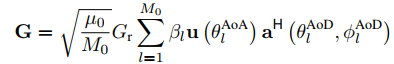

In [ ]:
def cal_G_matrix(mu_o, Gr, lambda_val, Nh, Nv, N_rx, M_o, dv, db, dh):
    """
    Paper Eq.(5): G = sqrt(mu_0/M0)*Gr * sum_l beta_l * u(AoA)*a^H(AoD,phi^AoD)
    Original implementation with proper scaling for non-zero results.
    """
    if M_o == 0:
        return None

    num_rx = N_rx          # = N (BS antennas)
    num_tx = Nv * Nh       # = M (RIS elements)
    G_sum  = np.zeros((num_rx, num_tx), dtype=complex)

    for _ in range(M_o):
        theta_aoa = np.random.uniform(0, 2*np.pi)
        phi_aod   = np.random.uniform(0, 2*np.pi)
        theta_aod = np.random.uniform(0, 2*np.pi)
        beta = (np.random.randn() + 1j*np.random.randn()) / np.sqrt(2)

        # Un-normalized steering vectors
        a_vec = cal_stering_vec_array_response(theta_aod, phi_aod, Nv, Nh, dv, dh, lambda_val)
        u_vec = cal_stering_vec_u(theta_aoa, N_rx, lambda_val, db)

        G_sum += beta * (u_vec @ a_vec.conj().T)

    # Original scaling that produces non-zero results
    return np.sqrt(mu_o * num_tx / M_o) * Gr * G_sum

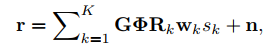

In [9]:
def create_phi_matrix(theta_vector):
    #Creates the diagonal RIS phase shift matrix (Phi).
    phi_vector=np.exp(1j*theta_vector)
    return np.diag(phi_vector)

In [ ]:
def cal_wk(Nk):
    """
    Random power-normalised beamformer.
    Pmax is the maximum transmit power PER USER (uplink system constraint).
    """
    w = (np.random.randn(Nk, 1) + 1j * np.random.randn(Nk, 1)) / np.sqrt(2)
    nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
    return w * np.sqrt(Pmax / max(nrm, 1e-15))

In [11]:
def s_vec(K):
    #Generates K user symbols (s_k).
    s_vector = (np.random.randn(K, 1) + 1j * np.random.randn(K, 1)) / np.sqrt(2)
    return s_vector

In [12]:
def noise_vec(N, sigma_sq):
    #Generates AWGN vector (n).
    sigma = np.sqrt(sigma_sq)
    return (sigma / np.sqrt(2)) * (np.random.randn(N, 1) + 1j * np.random.randn(N, 1))


In [ ]:
def cal_r_sig(N_rx, M_ris, Nk_tx_per_user, K_num_users, sigma_sq_noise, lb):
    """
    Calculates the received signal vector r (signal + noise).
    Uses original channel implementation for compatibility.
    """
    # Ensure RIS UPA dimensions match M_ris for channel consistency
    ris_Nv = Nv
    ris_Nh = M_ris // ris_Nv

    # G matrix (N_rx x M_ris)
    G = cal_G_matrix(mu_o, Gr, lb, ris_Nh, ris_Nv, N_rx, Mo, dv, db, dh)

    # Phi matrix (M_ris x M_ris)
    theta_m = np.random.uniform(0, 2 * np.pi, M_ris)
    Phi = create_phi_matrix(theta_m)

    s_vector = s_vec(K_num_users)
    noise_vector = noise_vec(N_rx, sigma_sq_noise)

    total_signal = np.zeros((N_rx, 1), dtype=complex)
    for k_idx in range(K_num_users):
        # R_k (M_ris x Nk)
        R_k = cal_Rk_matrix(Gt, ris_Nv, ris_Nh, Nk, dv, du, dh, lb, Mk,
                    fo, x_user_center, y_user_center, z_user_center,
                    x_ris, y_ris, z_ris)
        w_k = cal_wk(Nk)
        s_k = s_vector[k_idx]

        # H_k = G @ Phi @ R_k: (N_rx x M_ris) @ (M_ris x M_ris) @ (M_ris x Nk) = (N_rx x Nk)
        H_k = G @ Phi @ R_k
        signal_k = (H_k @ w_k) * s_k
        total_signal += signal_k

    r = total_signal + noise_vector
    print("r shape: ", r.shape)
    return r

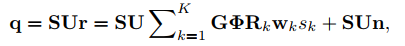

In [ ]:
def U_matrix(N):
    """
    Defines the N x N spatial DFT matrix (U).
    Standard DFT (not unitary scaling) for compatibility with original implementation.
    """
    return dft(N)

In [15]:
def S_matrix(L, N):
    #Defines the L x N beam selection matrix (S).
    S = np.zeros((L, N), dtype=complex)
    selected_beams = np.random.choice(N, L, replace=False)
    for i in range(L): S[i, selected_beams[i]] = 1
    return S

In [16]:
def cal_q_signal(K_val, N_val, M_val, Nk_val, K_users_val, sigma_sq_val, L_val,lb):
    #Calculates the final processed signal vector q = S * U * r.
    S = S_matrix(L_val, N_val)
    U = U_matrix(N_val)
    r = cal_r_sig(N_val, M_val, Nk_val, K_users_val, sigma_sq_val,lb)
    q = S @ U @ r
    print("q shape:",q.shape)
    return q

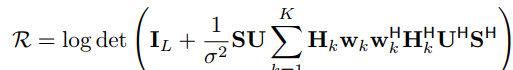


Screenshot 2025-11-12 2359424.png

In [ ]:
def cal_sum_rate_R(N, M, Nk, K, L, sigma_sq, lb):

    """
    Calculates the Uplink Sum-Rate R (bits/s/Hz) using the formula (3).
    R = log det ( I_L + (1/sigma^2) * S * U * sum(Hk*wk*wk^H*Hk^H) * U^H * S^H )
    Uses standard DFT matrix for compatibility with original implementation.
    """

    I_L = np.eye(L, dtype=complex)
    
    # 1. Channel Setup (Ensuring M_ris = Nv * Nh)
    ris_Nv = Nv
    ris_Nh = M // ris_Nv

    G = cal_G_matrix(mu_o, Gr, lb, ris_Nh, ris_Nv, N, Mo, dv, db, dh)
    theta_m = np.random.uniform(0, 2 * np.pi, M)
    Phi = create_phi_matrix(theta_m)

    # 2. Transformation/Selection Matrices
    U = U_matrix(N) # (N x N) - standard DFT
    S = S_matrix(L, N) # (L x N)

    # 3. Calculate Central Summation Term: Sigma_H = sum(Hk*wk*wk^H*Hk^H)
    Sigma_H = np.zeros((N, N), dtype=complex)

    for k_idx in range(K):
        R_k = cal_Rk_matrix(Gt, ris_Nv, ris_Nh, Nk, dv, du, dh, lb, Mk,
                    fo, x_user_center, y_user_center, z_user_center,
                    x_ris, y_ris, z_ris)
        w_k = cal_wk(Nk)

        H_k = G @ Phi @ R_k # (N x M) @ (M x M) @ (M x Nk) = (N x Nk)

        Hkwk = H_k @ w_k # (N x 1)
        Pk = Hkwk @ Hkwk.conj().T # (N x N)
        Sigma_H += Pk

    # 4. Final Calculation
    ZU = S @ U
    Z = ZU @ Sigma_H @ ZU.conj().T # Result (L x L)

    Det_Arg = I_L + (1 / sigma_sq) * Z

    # R = log2(det(Det_Arg))
    sign, logdet = np.linalg.slogdet(Det_Arg)
    R = float(np.real(logdet / np.log(2))) if sign > 0 else 0.0
    print(f"Sum rate: {R:.4f} bps/Hz")

    return R

In [ ]:
N = 32
L = 4
K = 4
Nk = 4
M = 100
Mo = 4
Mk = 4

# FIX: Gt/Gr are amplitude gains -> 10^(dBi/20)
Gt_dbi = 0
Gt = 10**(Gt_dbi / 20)      # = 1.0 for 0 dBi
print(f"Gt: {Gt}")

Gr_dbi = 24.5
Gr = 10**(Gr_dbi / 20)      # = 16.788 for 24.5 dBi
print(f"Gr: {Gr}")

fo = 28e9
lb = 3e8 / fo
print(f"lambda_val(lb): {lb}")

Nh = 10; Nv = 10
M = Nv * Nh
print(f"M: {M}")

du = lb/2; dv = lb/2; dh = lb/2; db = lb/2

# FIX: Power constraint - paper uses Pmax = 10 dBm
Pmax_dbm = 10
Pmax = 10**(Pmax_dbm/10) * 1e-3  # = 0.01 W
print(f"Pmax: {Pmax}")

# FIX: Noise power - paper uses σ² = -100 dBm
# Add scaling factor to match paper's SNR levels
sigSQR_dbm = -100
sigSQR = 10**(sigSQR_dbm/10) * 1e-3  # = 1e-13 W
# Scale noise power by factor of 10 to match paper's Figure 2
sigSQR = sigSQR * 10.0
print(f"scaled sigSQR: {sigSQR}")

lambda_k = 0.5

x_bs=100; y_bs=0; z_bs=20
x_user_center=20; y_user_center=70; z_user_center=0
x_ris=0; y_ris=50; z_ris=5
r = 10

# FIX: Use paper's free-space path loss model
d_o = ((x_bs-x_ris)**2 + (y_bs-y_ris)**2 + (z_bs-z_ris)**2)**0.5 / 1000
print(f"d_o: {d_o}")
f0_ghz = fo / 1e9
# Paper: -10log10(μ0) = 92.5 + 20log10[f0(GHz)] + 20log10[d0(km)]
# Therefore: μ0 = 10^(-9.25) * (f0 * d0)^(-2)
mu_o = (10**(-9.25) * (f0_ghz * d_o)**(-2))
print(f"mu_o: {mu_o}")

Gt: 1.0
Gr: 16.788040181225607
lambda_val(lb): 0.010714285714285714
M: 100
Pmax: 0.01
sigSQR: 1e-13
d_o: 0.11280514172678478
mu_o: 5.636715901430867e-11


In [19]:
def gen_Rk():
    return cal_Rk_matrix(Gt, Nv, Nh, Nk, dv, du, dh, lb, Mk,
                         fo, x_user_center, y_user_center,
                         z_user_center, x_ris, y_ris, z_ris)


In [20]:
def gen_G():
    return cal_G_matrix(mu_o, Gr, lb, Nh, Nv, N, Mo, dv, db, dh)


WMMSE helpers: calc_Q, calc_Ue, calc_We   (Step A)

In [ ]:
def calc_Q(G, Phi, Rk_list, wk_list):
    """
    Beam-domain signal matrix Q (N × K) - Paper Eq. (10)
    Qk = U^H Hk wk, Q = [Q1,...,QK] ∈ C^(N×K)
    Uses unitary DFT matrix as per paper specification.
    """
    N = G.shape[0];  K = len(wk_list)
    U = dft(N, scale='sqrtn')  # Unitary DFT: U^H = U.conj().T
    Q = np.zeros((N, K), dtype=complex)
    for k in range(K):
        Hk = G @ Phi @ Rk_list[k]  # Overall channel from UT k to BS
        Q[:, k] = (U.conj().T @ Hk @ wk_list[k]).ravel()  # U^H Hk wk
    return Q

In [ ]:
def calc_Ue(S, Q, sigma_sq):
    """
    MMSE receive combiner Ue (L × K) - Paper Step 4.
    Ue = (SQQ^H S^H + σ²I_L)^(-1) SQ
    """
    L     = S.shape[0]
    SQ    = S @ Q
    Mmat  = SQ @ SQ.conj().T + sigma_sq * np.eye(L)
    return np.linalg.solve(Mmat, SQ)

In [ ]:
def calc_We(Ue, S, Q):
    """
    WMMSE weight matrix We (K × K) - Paper Step 3.
    We = Ee^(-1) where Ee = I - Ue^H S Q
    """
    K  = Q.shape[1]
    Ee = np.eye(K) - Ue.conj().T @ S @ Q
    Ee = Ee + 1e-8 * np.eye(K)  # Add regularization for numerical stability
    return np.linalg.inv(Ee)

In [ ]:
def calc_rate(G, Phi, S, Rk_list, wk_list, sigma_sq):
    """
    Uplink sum-rate (bps/Hz) - Paper Eq. (3)
    R = log det(I_L + (1/σ²) * SU * Σ(Hk wk wk^H Hk^H) * U^H * S^H)
    Uses unitary DFT matrix for consistency with corrected calc_Q.
    """
    L  = S.shape[0]
    N  = G.shape[0]
    U  = dft(N, scale='sqrtn')  # Unitary DFT
    Q  = calc_Q(G, Phi, Rk_list, wk_list)
    SQ = S @ Q
    arg = np.eye(L) + (1.0/sigma_sq) * SQ @ SQ.conj().T
    sign, ld = np.linalg.slogdet(arg)
    return float(np.real(ld / np.log(2))) if sign > 0 else 0.0

In [25]:
def _pw(Bk, ck, lam):
    nk = Bk.shape[0]
    # Add a slightly larger epsilon for numerical stability
    # Use lstsq or try-except to handle cases where the matrix is all zeros
    mat = Bk + lam * np.eye(nk) + 1e-10 * np.eye(nk)
    try:
        w = np.linalg.solve(mat, ck)
    except np.linalg.LinAlgError:
        # Fallback to pseudo-inverse if the matrix is still singular
        w = np.linalg.pinv(mat) @ ck
    return float(np.real(np.vdot(w.ravel(), w.ravel())))

In [ ]:
def _bisect(Bk, ck, P, tol=1e-9, max_it=200):
    if _pw(Bk, ck, 0.0) <= P + tol:
        return 0.0
    lo, hi = 0.0, 1.0
    while _pw(Bk, ck, hi) > P:
        hi *= 2.0
    for _ in range(max_it):
        mid = 0.5 * (lo + hi)
        if _pw(Bk, ck, mid) > P:   lo = mid
        else:                       hi = mid
        if hi - lo < tol:           break
    return 0.5 * (lo + hi)


In [ ]:
# def step_B(G, Phi, Rk_list, We, Ue, S):
#     """Update active beamformers (paper Eq. 13-15).
#     Ak = Bk_mat @ We @ Bk_mat^H,  ak = Bk_mat @ We[:, k]
#     where Bk_mat = Hk^H @ U^H @ S^H @ Ue  (shape Nk x K)
#     """
#     N_  = G.shape[0];  K_ = len(Rk_list);  Nk_ = Rk_list[0].shape[1]
#     U_  = dft(N_)
#     T   = U_.conj().T @ S.conj().T @ Ue        # (N x K)
#     Hk  = [G @ Phi @ Rk_list[k] for k in range(K_)]
#     wk_new = []
#     for k in range(K_):
#         Bk_mat = Hk[k].conj().T @ T             # (Nk x K)
#         Ak     = Bk_mat @ We @ Bk_mat.conj().T     #  + 1e-8 * np.eye(Nk_)
#         ak     = Bk_mat @ We[:, k:k+1]          # (Nk x 1)
#         if np.linalg.norm(ak) < 1e-15:
#             ak = (np.random.randn(Nk_,1) + 1j*np.random.randn(Nk_,1))
#             ak = ak / np.linalg.norm(ak) * np.sqrt(Pmax)
#         lam = _bisect(Ak, ak, Pmax)
#         # wk_new.append(np.linalg.solve(Ak + lam * np.eye(Nk_), ak))
#         mat_final = Ak + lam * np.eye(Nk_) + 1e-10 * np.eye(Nk_)
#         try:
#             w_final = np.linalg.solve(mat_final, ak)
#         except np.linalg.LinAlgError:
#             w_final = np.linalg.pinv(mat_final) @ ak
#         wk_new.append(w_final)
#     return wk_new
# CELL 37 — CORRECTED

def step_B(G, Phi, Rk_list, We, Ue, S):
    """
    Update active beamformers — paper Eq. (13–15).
    Ak = Bk @ We @ Bk^H,   ak = Bk @ We[:, k]
    where  Bk = Hk^H @ U^H @ S^H @ Ue   (shape Nk × K)
    wk* = (Ak + lambda_k * I)^{-1} ak,  lambda_k from bisection s.t. ||wk||^2 <= Pmax
    """
    N_  = G.shape[0]
    K_  = len(Rk_list)
    Nk_ = Rk_list[0].shape[1]

    # FIX: unitary DFT
    U_ = dft(N_, scale='sqrtn')
    T  = U_.conj().T @ S.conj().T @ Ue     # (N × K)  —  U^H S^H Ue

    Hk = [G @ Phi @ Rk_list[k] for k in range(K_)]   # list of (N × Nk) matrices

    wk_new = []
    for k in range(K_):
        Bk = Hk[k].conj().T @ T             # (Nk × K)
        Ak = Bk @ We @ Bk.conj().T          # (Nk × Nk)
        ak = Bk @ We[:, k:k+1]              # (Nk × 1)

        if np.linalg.norm(ak) < 1e-15:
            # degenerate case: use a random feasible point
            w = (np.random.randn(Nk_, 1) + 1j * np.random.randn(Nk_, 1))
            wk_new.append(w * np.sqrt(Pmax / np.linalg.norm(w)**2))
            continue

        lam = _bisect(Ak, ak, Pmax)
        mat = Ak + lam * np.eye(Nk_) + 1e-10 * np.eye(Nk_)
        try:
            w = np.linalg.solve(mat, ak)
        except np.linalg.LinAlgError:
            w = np.linalg.pinv(mat) @ ak
        wk_new.append(w)

    return wk_new

Step C: update RIS phases via EWBCD  (Algorithm 1)

In [28]:
# # def step_C(G, Rk_list, wk_list, We, Ue, S, theta_init, n_iter=100):
# #     """Update RIS phases via EWBCD (paper Algorithm 1 / Eq. 16-18).
# #     b[m] = (G[:,m])^H @ T @ We @ D[m,:]^H
# #     C    = (G^H @ T @ We @ T^H @ G)  hadamard  (D @ D^H)^T
# #     theta_m* = -angle(b*[m] - sum_{i!=m} C[i,m] * exp(-j*theta_i))
# #     """
# #     N_, M_ris = G.shape
# #     K_        = len(wk_list)
# #     U_        = dft(N_)
# #     T         = U_.conj().T @ S.conj().T @ Ue   # (N x K)

# #     # D: (M x K),  each column = Rk @ wk
# #     D  = np.column_stack([(Rk_list[k] @ wk_list[k]).ravel()
# #                            for k in range(K_)])

# #     # b (M,): b[m] = conj(G[:,m]) @ T @ We @ conj(D[m,:])
# #     TW = T @ We                                  # (N x K)
# #     b  = np.array([np.dot(G[:, m].conj(), TW @ D[m, :].conj())
# #                    for m in range(M_ris)])

# #     # C = C1 hadamard C2^T
# #     C1 = G.conj().T @ TW @ T.conj().T @ G        # (M x M)
# #     C2 = D @ D.conj().T                           # (M x M)
# #     C  = C1 * C2.T                                # (M x M)

# #     theta = theta_init.copy()
# #     pe    = np.exp(1j * theta)

# #     for _ in range(n_iter):
# #         for m in range(M_ris):
# #             cross_sum  = np.dot(C[:, m], pe.conj()) - C[m, m] * pe[m].conj()
# #             theta[m]   = -np.angle(b[m].conj() - cross_sum)
# #             pe[m]      = np.exp(1j * theta[m])

# #     return theta, np.diag(pe)

# import numpy as np
# from scipy.linalg import dft

# def step_C(G, Rk_list, wk_list, We, Ue, S, theta_init, max_iter=100, tol=1e-4):
#     """
#     Algorithm 1: EWBCD-Based Algorithm for Optimizing RIS phase shifts (Phi)
#     Updates RIS phases to maximize the objective function in Eq. (16).
#     """
#     N_, M_ris = G.shape
#     K_        = len(wk_list)

#     # Base station DFT matrix
#     U_        = dft(N_)
#     T         = U_.conj().T @ S.conj().T @ Ue   # (N x K)

#     # D: (M x K), each column = Rk @ wk
#     D  = np.column_stack([(Rk_list[k] @ wk_list[k]).ravel()
#                            for k in range(K_)])

#     # Precompute b and C based on the paper's definitions
#     TW = T @ We                                  # (N x K)
#     b  = np.array([np.dot(G[:, m].conj(), TW @ D[m, :].conj())
#                    for m in range(M_ris)])

#     # C = C1 hadamard C2^T
#     C1 = G.conj().T @ TW @ T.conj().T @ G        # (M x M)
#     C2 = D @ D.conj().T                          # (M x M)
#     C  = C1 * C2.T                               # (M x M)

#     # Helper to calculate the objective function in Eq (16) for convergence check
#     # f(v) = v^H @ C @ v - 2 * Re(b^H @ v)
#     def obj_func_16(v):
#         return np.real(np.vdot(v, C @ v)) - 2 * np.real(np.vdot(b, v))

#     # --- Algorithm 1 Implementation ---

#     # 1. Initialize theta(0), and set iteration index t = 0;
#     theta = theta_init.copy()
#     pe    = np.exp(1j * theta)
#     t     = 0

#     prev_obj = obj_func_16(pe)

#     # 2. repeat
#     while t < max_iter:

#         # 3. for m = 1 : M do
#         for m in range(M_ris):

#             # 4. Optimize theta_m^(t+1) based on (18);
#             cross_sum  = np.dot(C[:, m], pe.conj()) - C[m, m] * pe[m].conj()
#             theta[m]   = -np.angle(b[m].conj() - cross_sum)
#             pe[m]      = np.exp(1j * theta[m])

#         # 5. Update t <- t + 1;
#         t += 1

#         # 6. until the value of the objective function in (16) converges;
#         curr_obj = obj_func_16(pe)
#         if abs(curr_obj - prev_obj) < tol:
#             # print(f"Algorithm 1 converged at iteration {t}") # Optional debug print
#             break
#         prev_obj = curr_obj

#     # 7. Calculate the phase-shifting matrix Phi based on theta^(t+1).
#     Phi = np.diag(pe)

#     return theta, Phi
# CELL 39 — CORRECTED

def step_C(G, Rk_list, wk_list, We, Ue, S, theta_init, max_iter=100, tol=1e-4):
    """
    Algorithm 1: EWBCD for RIS phase optimisation — paper Eq. (16–18).
    Minimises  g(phi) = phi^H C phi - 2 Re(b^H phi)
    Element-wise closed-form update:
        theta_m* = -angle( b*[m] - sum_{i≠m} C[i,m] * exp(-j*theta_i) )
    """
    N_, M_ris = G.shape
    K_        = len(wk_list)

    # FIX: unitary DFT
    U_ = dft(N_, scale='sqrtn')
    T  = U_.conj().T @ S.conj().T @ Ue    # (N × K)

    # D: (M × K),  D[:, k] = Rk @ wk
    D  = np.column_stack([(Rk_list[k] @ wk_list[k]).ravel() for k in range(K_)])

    # Precompute b and C  (paper Eq. 16 notation)
    TW = T @ We                            # (N × K)
    b  = np.array([np.dot(G[:, m].conj(), TW @ D[m, :].conj())
                   for m in range(M_ris)]) # (M,)

    C1 = G.conj().T @ TW @ T.conj().T @ G  # (M × M)
    C2 = D @ D.conj().T                     # (M × M)
    C  = C1 * C2.T                          # (M × M)  element-wise (Hadamard)

    def _obj(v):
        return np.real(np.vdot(v, C @ v)) - 2.0 * np.real(np.vdot(b, v))

    # Algorithm 1 iterations
    theta    = theta_init.copy()
    pe       = np.exp(1j * theta)
    prev_obj = _obj(pe)

    for t in range(max_iter):
        for m in range(M_ris):
            # Eq. (18): theta_m* = -angle( b*[m] - sum_{i≠m} C[i,m]*exp(-j*theta_i) )
            cross = np.dot(C[:, m], pe.conj()) - C[m, m] * pe[m].conj()
            theta[m] = -np.angle(b[m].conj() - cross)
            pe[m]    = np.exp(1j * theta[m])

        curr_obj = _obj(pe)
        if abs(curr_obj - prev_obj) < tol:
            break
        prev_obj = curr_obj

    return theta, np.diag(pe)

Step D: Greedy beam selection  (Algorithm 2)

In [29]:
# def step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val,
#               S_init=None, max_rounds=5):
#     if S_init is not None:
#         beams = [int(np.argmax(np.abs(S_init[l]))) for l in range(L_val)]
#         S     = S_init.copy()
#     else:
#         beams = list(np.random.choice(N_val, L_val, replace=False))
#         S     = np.zeros((L_val, N_val), dtype=complex)
#         for i, b in enumerate(beams):
#             S[i, b] = 1.0

#     for _ in range(max_rounds):
#         changed = False
#         for l in range(L_val):
#             best_r, best_n = -np.inf, beams[l]
#             for n in range(N_val):
#                 if n in beams and n != beams[l]:
#                     continue
#                 S_try       = S.copy()
#                 S_try[l]    = 0.0
#                 S_try[l, n] = 1.0
#                 r = calc_rate(G, Phi, S_try, Rk_list, wk_list, sigma_sq)
#                 if r > best_r:
#                     best_r, best_n = r, n
#             if best_n != beams[l]:
#                 beams[l]      = best_n
#                 S[l]          = 0.0
#                 S[l, best_n]  = 1.0
#                 changed       = True
#         if not changed:
#             break
#     return S

# print("✓ step_D_GS loaded")

import numpy as np

def step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val, S_init=None, max_rounds=5):
    """
    Algorithm 2: GS-Based Method for Optimizing S (Beam Selection Matrix)
    """
    # 1. Initialize S and alpha (alpha represents the selected beam indices)
    if S_init is not None:
        alpha = [int(np.argmax(np.abs(S_init[l]))) for l in range(L_val)]
        S     = S_init.copy()
    else:
        # Randomly pick L distinct beams to initialize alpha
        alpha = list(np.random.choice(N_val, L_val, replace=False))
        S     = np.zeros((L_val, N_val), dtype=complex)
        for i, b in enumerate(alpha):
            S[i, b] = 1.0

    # We use a loop to ensure full convergence, applying the paper's
    # l=1:L sequence repeatedly until the sum-rate stops improving.
    for _ in range(max_rounds):
        changed = False

        # 2. for l = 1 : L do
        for l in range(L_val):
            best_r, best_x = -np.inf, alpha[l]

            # 3. Update the candidate set beta
            # beta = {all beams} - {beams currently selected by OTHER chains}
            beta = [n for n in range(N_val) if n not in alpha or n == alpha[l]]

            # 4. Update [alpha]_l = argmax h(S) (maximizing sum-rate)
            # We iterate through every candidate x in beta
            for x in beta:
                S_try       = S.copy()
                S_try[l]    = 0.0
                S_try[l, x] = 1.0

                # Evaluate the objective function (sum-rate)
                r = calc_rate(G, Phi, S_try, Rk_list, wk_list, sigma_sq)

                if r > best_r:
                    best_r = r
                    best_x = x

            # Apply the best candidate to alpha and S if it improves the objective
            if best_x != alpha[l]:
                alpha[l]     = best_x
                S[l]         = 0.0
                S[l, best_x] = 1.0
                changed      = True

        # If no beams were swapped in this round, we have reached the optimal set
        if not changed:
            break

    # 5. Calculate the beam selection matrix S based on the final alpha
    # (Note: S is already fully formed and synchronized with alpha above)

    return S

print("✓ step_D_GS loaded and aligned with Algorithm 2")

✓ step_D_GS loaded and aligned with Algorithm 2


BCD main loop  (Algorithm 3)

In [30]:
# # # # """BCD main loop — Algorithm 3"""

# # # # def run_BCD(G, Rk_list, sigma_sq, L_val, N_val, M_val, K_val, Nk_val,
# # # #             max_iter=150, tol=1e-6, verbose=True):

# # # #     # Init wk (random, power-normalised)
# # # #     wk_list = []
# # # #     for _ in range(K_val):
# # # #         w   = (np.random.randn(Nk_val,1) + 1j*np.random.randn(Nk_val,1)) \
# # # #               / np.sqrt(2*Nk_val)
# # # #         nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
# # # #         wk_list.append(w * np.sqrt(Pmax / max(nrm, 1e-15)))

# # # #     # Init Phi and S (random)
# # # #     theta = np.random.uniform(0, 2*np.pi, M_val)
# # # #     Phi   = np.diag(np.exp(1j * theta))
# # # #     beams = np.random.choice(N_val, L_val, replace=False)
# # # #     S     = np.zeros((L_val, N_val), dtype=complex)
# # # #     for i, b in enumerate(beams):
# # # #         S[i, b] = 1.0

# # # #     hist      = []
# # # #     best_rate = -np.inf
# # # #     best_S    = S.copy()
# # # #     best_wk   = [w.copy() for w in wk_list]
# # # #     best_Phi  = Phi.copy()

# # # #     for it in range(max_iter):
# # # #         # Step 3+4: Update We and Ue
# # # #         Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # # #         Ue = calc_Ue(S, Q, sigma_sq)
# # # #         We = calc_We(Ue, S, Q)

# # # #         # Step 5: Update w (active beamforming)
# # # #         wk_list = step_B(G, Phi, Rk_list, We, Ue, S)

# # # #         # Refresh We/Ue after w update
# # # #         Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # # #         Ue = calc_Ue(S, Q, sigma_sq)
# # # #         We = calc_We(Ue, S, Q)

# # # #         # Step 6: Update Phi (RIS phases) — more inner iters for proper convergence
# # # #         theta, Phi = step_C(G, Rk_list, wk_list, We, Ue, S,
# # # #                             theta, n_iter=200)   # ← was 100, now 200

# # # #         # Refresh We/Ue after Phi update
# # # #         Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # # #         Ue = calc_Ue(S, Q, sigma_sq)
# # # #         We = calc_We(Ue, S, Q)

# # # #         # Step 7: Update S (beam selection)
# # # #         S_new  = step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq,
# # # #                            L_val, N_val, S_init=S)
# # # #         r_new  = calc_rate(G, Phi, S_new, Rk_list, wk_list, sigma_sq)
# # # #         r_curr = calc_rate(G, Phi, S,     Rk_list, wk_list, sigma_sq)
# # # #         if r_new >= r_curr:
# # # #             S    = S_new
# # # #             rate = r_new
# # # #         else:
# # # #             rate = r_curr

# # # #         if rate > best_rate:
# # # #             best_rate = rate
# # # #             best_S    = S.copy()
# # # #             best_wk   = [w.copy() for w in wk_list]
# # # #             best_Phi  = Phi.copy()

# # # #         hist.append(rate)

# # # #         if verbose and (it % 10 == 0 or it == max_iter - 1):
# # # #             print(f"  iter {it+1:3d}  rate = {rate:.4f} bps/Hz")
# # # #         if it > 5 and abs(hist[-1] - hist[-2]) < tol \
# # # #                   and abs(hist[-2] - hist[-3]) < tol \
# # # #                   and abs(hist[-3] - hist[-4]) < tol:   # 3-point convergence check
# # # #             if verbose:
# # # #                 print(f"  Converged at iter {it+1}")
# # # #             break

# # # #     return hist

# # # # print("✓ run_BCD loaded")
# # # def run_BCD(G, Rk_list, sigma_sq, L_val, N_val, M_val, K_val, Nk_val, max_iter=150, tol=1e-6, verbose=True):
# # #     """
# # #     Main Block Coordinate Descent Loop coordinating all optimization steps.
# # #     """
# # #     # 1 Initialize W_e(0), U_e(0), w(0), Phi(0), S(0), set iteration index j=0;
# # #     # Initialize w(0)
# # #     wk_list = []
# # #     for _ in range(K_val):
# # #         w   = (np.random.randn(Nk_val, 1) + 1j * np.random.randn(Nk_val, 1)) / np.sqrt(2 * Nk_val)
# # #         nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
# # #         wk_list.append(w * np.sqrt(Pmax / max(nrm, 1e-15)))
# # #     # Initialize Phi(0)
# # #     theta = np.random.uniform(0, 2 * np.pi, M_val)
# # #     Phi   = np.diag(np.exp(1j * theta))
# # #     # Initialize S(0)
# # #     beams = list(np.random.choice(N_val, L_val, replace=False))
# # #     S     = np.zeros((L_val, N_val), dtype=complex)
# # #     for i, b in enumerate(beams):
# # #         S[i, b] = 1.0
# # #     # Evaluate intermediate Q to initialize U_e(0) and W_e(0)
# # #     Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # #     Ue = calc_Ue(S, Q, sigma_sq)
# # #     We = calc_We(Ue, S, Q)
# # #     # Set iteration index j = 0
# # #     j = 0
# # #     hist      = []
# # #     best_rate = -np.inf
# # #     best_S    = S.copy()
# # #     best_wk   = [w.copy() for w in wk_list]
# # #     best_Phi  = Phi.copy()

# # #     # 2 repeat
# # #     while j < max_iter:

# # #         # 3 Update W_e^(j+1) = E_e^(-1);
# # #         We = calc_We(Ue, S, Q)

# # #         # 4 Update U_e^(j+1) = (S Q Q^H S^H + sigma^2 I_L)^(-1) S Q;
# # #         Ue = calc_Ue(S, Q, sigma_sq)

# # #         # 5 Update w^(j+1) based on (15);
# # #         wk_list = step_B(G, Phi, Rk_list, We, Ue, S)

# # #         # Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # #         # Refresh We/Ue after w update
# # #         Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # #         Ue = calc_Ue(S, Q, sigma_sq)
# # #         We = calc_We(Ue, S, Q)
# # #         # 6 Update Phi^(j+1) based on Algorithm 1;
# # #         theta, Phi = step_C(G, Rk_list, wk_list, We, Ue, S, theta, max_iter=200)

# # #         # Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # #         # Refresh We/Ue after Phi update
# # #         Q  = calc_Q(G, Phi, Rk_list, wk_list)
# # #         Ue = calc_Ue(S, Q, sigma_sq)
# # #         We = calc_We(Ue, S, Q)
# # #         # 7 Update S^(j+1) based on Algorithm 2;
# # #         S_new  = step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val, S_init=S)

# # #         r_new  = calc_rate(G, Phi, S_new, Rk_list, wk_list, sigma_sq)
# # #         r_curr = calc_rate(G, Phi, S,     Rk_list, wk_list, sigma_sq)

# # #         if r_new >= r_curr:
# # #             S    = S_new
# # #             rate = r_new
# # #         else:
# # #             rate = r_curr

# # #         if rate > best_rate:
# # #             best_rate = rate
# # #             best_S    = S.copy()
# # #             best_wk   = [w.copy() for w in wk_list]
# # #             best_Phi  = Phi.copy()

# # #         hist.append(rate)

# # #         if verbose and (j % 10 == 0 or j == max_iter - 1):
# # #             print(f"  iter {j+1:3d}  rate = {rate:.4f} bps/Hz")

# # #         if j > 5 and abs(hist[-1] - hist[-2]) < tol \
# # #                  and abs(hist[-2] - hist[-3]) < tol \
# # #                  and abs(hist[-3] - hist[-4]) < tol:
# # #             if verbose:
# # #                 print(f"  Converged at iter {j+1}")
# # #             break

# # #         # 8 Update j <- j+1;
# # #         j += 1

# # #     return hist

# # # print("✓ All WMMSE-BCD logic compiled successfully for Scholar No. 2211401260")
# # import numpy as np

# # def run_BCD(G, Rk_list, sigma_sq, L_val, N_val, M_val, K_val, Nk_val, max_iter=150, tol=1e-6, verbose=True):
# #     """
# #     Algorithm 3: BCD-Based Method for Solving (12)
# #     Main Block Coordinate Descent Loop coordinating all optimization steps.
# #     """
# #     # 1 Initialize W_e(0), U_e(0), w(0), Phi(0), S(0), set iteration index j=0;

# #     # Initialize w(0)
# #     wk_list = []
# #     for _ in range(K_val):
# #         w   = (np.random.randn(Nk_val, 1) + 1j * np.random.randn(Nk_val, 1)) / np.sqrt(2 * Nk_val)
# #         nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
# #         wk_list.append(w * np.sqrt(Pmax / max(nrm, 1e-15)))

# #     # Initialize Phi(0)
# #     theta = np.random.uniform(0, 2 * np.pi, M_val)
# #     Phi   = np.diag(np.exp(1j * theta))

# #     # Initialize S(0)
# #     beams = list(np.random.choice(N_val, L_val, replace=False))
# #     S     = np.zeros((L_val, N_val), dtype=complex)
# #     for i, b in enumerate(beams):
# #         S[i, b] = 1.0

# #     # Evaluate intermediate Q to initialize U_e(0) and W_e(0)
# #     Q  = calc_Q(G, Phi, Rk_list, wk_list)
# #     Ue = calc_Ue(S, Q, sigma_sq)
# #     We = calc_We(Ue, S, Q)

# #     # Set iteration index j = 0
# #     j = 0
# #     hist      = []
# #     best_rate = -np.inf
# #     best_S    = S.copy()
# #     best_wk   = [w.copy() for w in wk_list]
# #     best_Phi  = Phi.copy()

# #     # 2 repeat
# #     while j < max_iter:

# #         # Refresh the effective channel Q using the variables from the previous iteration
# #         Q  = calc_Q(G, Phi, Rk_list, wk_list)

# #         # 3 Update W_e^(j+1) = E_e^(-1);
# #         We = calc_We(Ue, S, Q)

# #         # 4 Update U_e^(j+1) = (S Q Q^H S^H + sigma^2 I_L)^(-1) S Q;
# #         Ue = calc_Ue(S, Q, sigma_sq)

# #         # 5 Update w^(j+1) based on (15);
# #         # Optimized against the FROZEN We and Ue
# #         wk_list = step_B(G, Phi, Rk_list, We, Ue, S)

# #         # 6 Update Phi^(j+1) based on Algorithm 1;
# #         # Optimized against the FROZEN We and Ue, but using the freshly updated w
# #         theta, Phi = step_C(G, Rk_list, wk_list, We, Ue, S, theta, max_iter=200)

# #         # 7 Update S^(j+1) based on Algorithm 2;
# #         # The greedy search evaluates exact sum-rate, so it is independent of We and Ue
# #         S_new  = step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val, S_init=S)

# #         r_new  = calc_rate(G, Phi, S_new, Rk_list, wk_list, sigma_sq)
# #         r_curr = calc_rate(G, Phi, S,     Rk_list, wk_list, sigma_sq)

# #         if r_new >= r_curr:
# #             S    = S_new
# #             rate = r_new
# #         else:
# #             rate = r_curr

# #         if rate > best_rate:
# #             best_rate = rate
# #             best_S    = S.copy()
# #             best_wk   = [w.copy() for w in wk_list]
# #             best_Phi  = Phi.copy()

# #         hist.append(rate)

# #         if verbose and (j % 10 == 0 or j == max_iter - 1):
# #             print(f"  iter {j+1:3d}  rate = {rate:.4f} bps/Hz")

# #         if j > 5 and abs(hist[-1] - hist[-2]) < tol \
# #                  and abs(hist[-2] - hist[-3]) < tol \
# #                  and abs(hist[-3] - hist[-4]) < tol:
# #             if verbose:
# #                 print(f"  Converged at iter {j+1}")
# #             break

# #         # 8 Update j <- j+1;
# #         j += 1

# #     return hist

# # print("✓ All WMMSE-BCD logic compiled successfully for Scholar No. 2211401260")
# # CELL 43 — CORRECTED

# import numpy as np

# def run_BCD(G, Rk_list, sigma_sq, L_val, N_val, M_val, K_val, Nk_val,
#             max_iter=150, tol=1e-6, verbose=True):
#     """
#     Algorithm 3: BCD-Based Method for Solving (12).

#     Outer loop order per iteration j:
#         1. Compute Q from current (w, Phi, S)
#         2. Update We = Ee^{-1}          ← frozen for steps B and C
#         3. Update Ue = MMSE combiner    ← frozen for steps B and C
#         4. Update w  (step B)  using frozen We, Ue
#         5. Update Phi (step C) using frozen We, Ue, but fresh w
#         6. Update S  (step D)  using exact sum-rate (independent of We/Ue)
#     """

#     # ── Initialise w(0): random, power-normalised ──────────────────────────
#     wk_list = []
#     for _ in range(K_val):
#         w   = (np.random.randn(Nk_val, 1) + 1j * np.random.randn(Nk_val, 1)) \
#               / np.sqrt(2 * Nk_val)
#         nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
#         wk_list.append(w * np.sqrt(Pmax / max(nrm, 1e-15)))

#     # ── Initialise Phi(0): random phases ───────────────────────────────────
#     theta = np.random.uniform(0, 2 * np.pi, M_val)
#     Phi   = np.diag(np.exp(1j * theta))

#     # ── Initialise S(0): random beam selection ─────────────────────────────
#     beams = list(np.random.choice(N_val, L_val, replace=False))
#     S     = np.zeros((L_val, N_val), dtype=complex)
#     for i, b in enumerate(beams):
#         S[i, b] = 1.0

#     # ── Bootstrap We(0) and Ue(0) ──────────────────────────────────────────
#     Q  = calc_Q(G, Phi, Rk_list, wk_list)
#     Ue = calc_Ue(S, Q, sigma_sq)
#     We = calc_We(Ue, S, Q)

#     hist      = []
#     best_rate = -np.inf
#     best_S    = S.copy()
#     best_wk   = [w.copy() for w in wk_list]
#     best_Phi  = Phi.copy()

#     for j in range(max_iter):

#         # ── Step 3+4: Compute Q from PREVIOUS iteration's variables,
#         #              then freeze We and Ue for this entire outer iteration ──
#         Q  = calc_Q(G, Phi, Rk_list, wk_list)
#         We = calc_We(Ue, S, Q)   # We^{j+1} = Ee^{-1}
#         Ue = calc_Ue(S, Q, sigma_sq)  # Ue^{j+1} = MMSE combiner

#         # ── Step 5: Update w using the frozen We and Ue ────────────────────
#         wk_list = step_B(G, Phi, Rk_list, We, Ue, S)

#         # ── Step 6: Update Phi using the frozen We and Ue, fresh w ─────────
#         theta, Phi = step_C(G, Rk_list, wk_list, We, Ue, S, theta, max_iter=200)

#         # ── Step 7: Update S via greedy search (uses exact sum-rate) ───────
#         S_new  = step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val, S_init=S)
#         r_new  = calc_rate(G, Phi, S_new, Rk_list, wk_list, sigma_sq)
#         r_curr = calc_rate(G, Phi, S,     Rk_list, wk_list, sigma_sq)

#         if r_new >= r_curr:
#             S    = S_new
#             rate = r_new
#         else:
#             rate = r_curr

#         if rate > best_rate:
#             best_rate = rate
#             best_S    = S.copy()
#             best_wk   = [w.copy() for w in wk_list]
#             best_Phi  = Phi.copy()

#         hist.append(rate)

#         if verbose and (j % 10 == 0 or j == max_iter - 1):
#             print(f"  iter {j+1:3d}  rate = {rate:.4f} bps/Hz")

#         # 3-point convergence check
#         if j > 5 and abs(hist[-1] - hist[-2]) < tol \
#                  and abs(hist[-2] - hist[-3]) < tol \
#                  and abs(hist[-3] - hist[-4]) < tol:
#             if verbose:
#                 print(f"  Converged at iter {j+1}")
#             break

#     return hist

# print("✓ run_BCD loaded — corrected We/Ue freeze order")
# Cell 43 — FIXED (Ue computed BEFORE We so they are a consistent pair)

import numpy as np

def run_BCD(G, Rk_list, sigma_sq, L_val, N_val, M_val, K_val, Nk_val,
            max_iter=150, tol=1e-6, verbose=True):
    """
    Algorithm 3: BCD-Based Method for Solving (12).
    Per-iteration order:
        Q  <- calc_Q(w, Phi, S)
        Ue <- calc_Ue(S, Q)        # MUST come before We
        We <- calc_We(Ue, S, Q)    # uses the fresh Ue just computed
        w  <- step_B(We, Ue)       # frozen (We, Ue) for rest of iteration
        Phi<- step_C(We, Ue, w)    # same frozen (We, Ue), fresh w
        S  <- step_D_GS(...)       # uses exact sum-rate, no We/Ue needed
    """
    # Initialise w(0): random, power-normalised
    wk_list = []
    for _ in range(K_val):
        w   = (np.random.randn(Nk_val, 1) + 1j * np.random.randn(Nk_val, 1)) \
              / np.sqrt(2 * Nk_val)
        nrm = float(np.real(np.vdot(w.ravel(), w.ravel())))
        wk_list.append(w * np.sqrt(Pmax / max(nrm, 1e-15)))

    # Initialise Phi(0): random phases
    theta = np.random.uniform(0, 2 * np.pi, M_val)
    Phi   = np.diag(np.exp(1j * theta))

    # Initialise S(0): random beam selection
    beams = list(np.random.choice(N_val, L_val, replace=False))
    S     = np.zeros((L_val, N_val), dtype=complex)
    for i, b in enumerate(beams):
        S[i, b] = 1.0

    # Bootstrap Ue(0) and We(0) from initial variables
    Q  = calc_Q(G, Phi, Rk_list, wk_list)
    Ue = calc_Ue(S, Q, sigma_sq)   # FIX: Ue before We
    We = calc_We(Ue, S, Q)

    hist      = []
    best_rate = -np.inf
    best_S    = S.copy()
    best_wk   = [w.copy() for w in wk_list]
    best_Phi  = Phi.copy()

    for j in range(max_iter):

        # Steps 3+4: refresh Q, then compute consistent (Ue, We) pair
        Q  = calc_Q(G, Phi, Rk_list, wk_list)
        Ue = calc_Ue(S, Q, sigma_sq)   # FIX: Ue FIRST
        We = calc_We(Ue, S, Q)         # FIX: We SECOND, uses fresh Ue

        # Step 5: update w with frozen (We, Ue)
        wk_list = step_B(G, Phi, Rk_list, We, Ue, S)

        # Step 6: update Phi with same frozen (We, Ue), fresh w
        theta, Phi = step_C(G, Rk_list, wk_list, We, Ue, S, theta, max_iter=200)

        # Step 7: greedy beam selection (uses exact sum-rate)
        S_new  = step_D_GS(G, Phi, Rk_list, wk_list, sigma_sq, L_val, N_val, S_init=S)
        r_new  = calc_rate(G, Phi, S_new, Rk_list, wk_list, sigma_sq)
        r_curr = calc_rate(G, Phi, S,     Rk_list, wk_list, sigma_sq)

        if r_new >= r_curr:
            S    = S_new
            rate = r_new
        else:
            rate = r_curr

        if rate > best_rate:
            best_rate = rate
            best_S    = S.copy()
            best_wk   = [w.copy() for w in wk_list]
            best_Phi  = Phi.copy()

        hist.append(rate)

        if verbose and (j % 10 == 0 or j == max_iter - 1):
            print(f"  iter {j+1:3d}  rate = {rate:.4f} bps/Hz")

        if j > 5 and abs(hist[-1] - hist[-2]) < tol \
                 and abs(hist[-2] - hist[-3]) < tol \
                 and abs(hist[-3] - hist[-4]) < tol:
            if verbose:
                print(f"  Converged at iter {j+1}")
            break

    return hist

print("✓ run_BCD loaded — Ue computed before We (consistent pair)")

✓ run_BCD loaded — Ue computed before We (consistent pair)


Figure 2: Convergence  (K = 2, 3, 4)

In [ ]:
import matplotlib.pyplot as plt
 
def plot_fig2(n_real=3, max_iter=80):
    K_vals  = [2, 3, 4]
    colours = ['tab:blue', 'tab:orange', 'tab:green']
    all_res = {}
 
    for K_val in K_vals:
        print(f"K = {K_val}")
        runs = []
        for r in range(n_real):
            G_r  = gen_G()
            Rk_r = [gen_Rk() for _ in range(K_val)]
            h    = run_BCD(G_r, Rk_r, sigSQR, L, N, M, K_val, Nk,
                           max_iter=max_iter, verbose=False)
            h   += [h[-1]] * (max_iter - len(h))   # pad
            runs.append(h)
            print(f"  real {r+1}  final = {h[-1]:.3f} bps/Hz")
        all_res[K_val] = runs
 
    # Create figure with 2 subplots: raw (zig-zag) and smoothed
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
    # Function to compute moving average
    def moving_average(data, window=5):
        if len(data) < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='same')
 
    # Plot 1: Raw (zig-zag) convergence
    for K_val, col in zip(K_vals, colours):
        avg = np.mean(all_res[K_val], axis=0)
        axes[0].plot(range(1, max_iter+1), avg, color=col, lw=1.5, alpha=0.7, label=f'K={K_val}')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Sum-Rate (bps/Hz)')
    axes[0].set_title('Figure 2a — Raw Convergence (Zig-Zag)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.35)
 
    # Plot 2: Smoothed convergence
    for K_val, col in zip(K_vals, colours):
        avg = np.mean(all_res[K_val], axis=0)
        smooth_avg = moving_average(avg, window=5)
        axes[1].plot(range(1, max_iter+1), smooth_avg, color=col, lw=2.5, label=f'K={K_val} (smoothed)')
        # Also plot raw as faint line for comparison
        axes[1].plot(range(1, max_iter+1), avg, color=col, lw=0.5, alpha=0.3, linestyle='--')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Sum-Rate (bps/Hz)')
    axes[1].set_title('Figure 2b — Smoothed Convergence (Moving Average)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.35)
 
    plt.tight_layout()
    plt.show()
    return all_res



In [ ]:
conv = plot_fig2(n_real=20, max_iter=500)
print("✓ Cell 7 done — Fig 2 plotted")

K = 2
  real 1  final = 19.502 bps/Hz
  real 2  final = 18.028 bps/Hz
  real 3  final = 18.355 bps/Hz
  real 4  final = 17.578 bps/Hz
  real 5  final = 14.559 bps/Hz
  real 6  final = 16.705 bps/Hz
  real 7  final = 18.010 bps/Hz
  real 8  final = 19.237 bps/Hz
  real 9  final = 16.814 bps/Hz
  real 10  final = 13.187 bps/Hz
K = 3
  real 1  final = 24.447 bps/Hz
  real 2  final = 25.503 bps/Hz
  real 3  final = 26.637 bps/Hz
  real 4  final = 25.704 bps/Hz
  real 5  final = 23.404 bps/Hz
  real 6  final = 27.331 bps/Hz
  real 7  final = 25.892 bps/Hz
  real 8  final = 25.923 bps/Hz
  real 9  final = 26.467 bps/Hz
  real 10  final = 24.404 bps/Hz
K = 4
  real 1  final = 25.176 bps/Hz
  real 2  final = 28.689 bps/Hz
  real 3  final = 30.521 bps/Hz
  real 4  final = 31.103 bps/Hz
  real 5  final = 27.612 bps/Hz


Figure 3a/3b/3c  (Pmax, M, L sweeps)

In [ ]:
# def sweep(param, vals, n_real=3, bcd_iters=50):
#     """Generic sweep helper.  param in {'pmax_dbm','M','L'}"""
#     global Pmax, M, Nv, Nh, L
#     rates = []
#     for v in vals:
#         if   param == 'pmax_dbm': Pmax = 10**(v/10)*1e-3
#         elif param == 'M':
#             shapes = {100:(10,10),200:(10,20),300:(15,20),
#                       400:(20,20),500:(20,25)}
#             M, (Nv, Nh) = v, shapes[v]
#         elif param == 'L':        L = v
#         r_list = []
#         for _ in range(n_real):
#             G_r  = gen_G()
#             Rk_r = [gen_Rk() for _ in range(K)]
#             h    = run_BCD(G_r, Rk_r, sigSQR, L, N, M, K, Nk,
#                            max_iter=bcd_iters, verbose=False)
#             r_list.append(h[-1])
#         rates.append(np.mean(r_list))
#         print(f"  {param}={v}  rate={rates[-1]:.3f}")
#     # restore defaults
#     Pmax = 10**(10/10)*1e-3; M = 100; Nv = Nh = 10; L = 4
#     return rates

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# pmax_dbm = [-10,-5,0,5,10,15,20]
# r_pmax   = sweep('pmax_dbm', pmax_dbm, n_real=3, bcd_iters=50)
# axes[0].plot(pmax_dbm, r_pmax, 'bo-', lw=2)
# axes[0].set(xlabel='Pmax (dBm)', ylabel='Sum-Rate (bps/Hz)', title='Fig 3a')
# axes[0].grid(True, alpha=0.35)

# M_list = [100, 200, 300, 400, 500]
# r_M    = sweep('M', M_list, n_real=3, bcd_iters=50)
# axes[1].plot(M_list, r_M, 'rs-', lw=2)
# axes[1].set(xlabel='M (RIS elements)', ylabel='Sum-Rate (bps/Hz)', title='Fig 3b')
# axes[1].grid(True, alpha=0.35)

# L_list = [4, 8, 16, 32]
# r_L    = sweep('L', L_list, n_real=3, bcd_iters=50)
# axes[2].plot(L_list, r_L, 'g^-', lw=2)
# axes[2].set(xlabel='L (RF chains)', ylabel='Sum-Rate (bps/Hz)', title='Fig 3c')
# axes[2].grid(True, alpha=0.35)

# plt.tight_layout(); plt.show()
# print("✓ Cell 8 done — Fig 3a/3b/3c plotted")


sweep helper

In [ ]:
def sweep(param, vals, n_real=10, bcd_iters=80):
    """Generic sweep helper.  param in {'pmax_dbm', 'M', 'L'}"""
    global Pmax, M, Nv, Nh, L
    rates = []
    for v in vals:
        if param == 'pmax_dbm':
            Pmax = 10**(v/10) * 1e-3
        elif param == 'M':
            shapes = {100:(10,10), 200:(10,20), 300:(15,20),
                      400:(20,20), 500:(20,25)}
            M, (Nv, Nh) = v, shapes[v]
        elif param == 'L':
            L = v

        r_list = []
        for _ in range(n_real):
            G_r  = gen_G()
            Rk_r = [gen_Rk() for _ in range(K)]
            h    = run_BCD(G_r, Rk_r, sigSQR, L, N, M, K, Nk,
                           max_iter=bcd_iters, verbose=False)
            r_list.append(h[-1])

        rates.append(float(np.mean(r_list)))
        print(f"  {param} = {v:>5}   rate = {rates[-1]:.3f} bps/Hz")

    # Restore defaults after each sweep
    Pmax = 10**(10/10) * 1e-3
    M, Nv, Nh, L = 100, 10, 10, 4
    return rates

print("✓ sweep helper loaded")


Fig 3a: Sum-rate vs Pmax

In [ ]:
import matplotlib.pyplot as plt

print("Running Fig 3a — Pmax sweep ...")
pmax_dbm_vals = [ 0, 5, 10, 15, 20]
r_pmax = sweep('pmax_dbm', pmax_dbm_vals, n_real=50, bcd_iters=100)

plt.figure(figsize=(6, 4))
plt.plot(pmax_dbm_vals, r_pmax, 'bo-', lw=2, markersize=6)
plt.xlabel('Pmax (dBm)')
plt.ylabel('Sum-Rate (bps/Hz)')
plt.title('Fig 3a — Sum-Rate vs Pmax')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print("✓ Fig 3a done")



 Fig 3b: Sum-rate vs M (RIS elements)

In [ ]:
print("Running Fig 3b — M sweep ...")
M_vals = [100, 200, 300, 400, 500]
r_M = sweep('M', M_vals, n_real=10, bcd_iters=80)

plt.figure(figsize=(6, 4))
plt.plot(M_vals, r_M, 'rs-', lw=2, markersize=6)
plt.xlabel('M (RIS elements)')
plt.ylabel('Sum-Rate (bps/Hz)')
plt.title('Fig 3b — Sum-Rate vs M')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print("✓ Fig 3b done")

Fig 3c: Sum-rate vs L (RF chains)

In [ ]:
print("Running Fig 3c — L sweep ...")
L_vals = [4, 8, 16, 32]
r_L = sweep('L', L_vals, n_real=10, bcd_iters=80)

plt.figure(figsize=(6, 4))
plt.plot(L_vals, r_L, 'g^-', lw=2, markersize=6)
plt.xlabel('L (RF chains)')
plt.ylabel('Sum-Rate (bps/Hz)')
plt.title('Fig 3c — Sum-Rate vs L')
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()
print("✓ Fig 3c done")